In [1]:
import numpy as np
import pandas as pd

np.random.seed(91284783)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
incentives = ['Cocopuff', 'Yoggie', 'M&M']
data = []

for n, day in enumerate(days):
    # Determine number of pee and poop events
    if day == 'Mon':
        num_pee = int(np.floor(np.random.normal(16,2)))
        num_poo = 0
    elif day == 'Tue':
        num_pee = int(np.floor(np.random.normal(12,3)))
        num_poo = 0
    else:
        num_pee = int(np.floor(np.random.normal(8, 2)))
        num_poo = 1

    # Split pee into morning and afternoon
    morn_pee = int(np.floor((num_pee / 2) + (num_pee % 2)))
    aft_pee = int(np.floor(num_pee / 2))

    # Function for probabilistic incentive selection per day
    def choose_incentive(day):
        rand_vals = np.random.rand(len(incentives))
        if day in ['Mon', 'Tue']:
            rand_vals[0] += 0.6
        elif day == 'Wed':
            rand_vals[1] += 0.6
        else:  # Thu, Fri
            rand_vals[2] += 0.6
        prob_vector = rand_vals / rand_vals.sum()
        return incentives[np.argmax(prob_vector)]

    # Generate pee events
    for i in range(morn_pee + aft_pee):
        # ToD split morning/afternoon
        tod = np.random.randint(7,12) + np.random.randint(0,60)/60 if i < morn_pee else np.random.randint(12,21) + np.random.randint(0,60)/60
        tup = max(5, int(np.random.normal(35,40)))
        outcome = '#1'
        # Randomized location per event
        if day == 'Mon':
            loc = 'Upstairs'
        else:
            loc = np.random.choice(['Upstairs','Downstairs'], p=[0.65,0.35])

        # Adjust TuP for downstairs
        if loc == 'Downstairs':
            tup += np.random.randint(46,90)  # slightly longer

        # Probabilistic book reading based on time and location noise
        base_prob = 0.05 + max(0, (tup-40)/5)*0.02
        if loc == 'Downstairs':
            base_prob += 0.1  # more likely to read books downstairs
        base_prob = min(base_prob, 0.95)
        book = np.random.choice(['Y','N'], p=[base_prob, 1-base_prob])

        # If book is read, slightly increase TuP
        if book == 'Y':
            tup += np.random.randint(60,120)

        incentive = choose_incentive(day)

        data.append({'day':day,'ToD':tod,'TuP':tup,'outcome':outcome,'location':loc,'book':book,'incentive':incentive})

    # Generate poop events (only 10am - 12pm)
    for i in range(num_poo):
        tod = np.random.randint(10,12) + np.random.randint(0,60)/60  # restricted to 10-12
        tup = max(10, int(np.random.normal(60,10)))
        outcome = '#2'
        loc = np.random.choice(['Upstairs','Downstairs'], p=[0.55,0.45])

        if loc == 'Downstairs':
            tup += np.random.randint(2,6)

        prob_book = 0.5 + max(0, (tup-60)/5)*0.02
        if loc == 'Downstairs':
            prob_book += 0.1
        prob_book = min(prob_book, 0.95)
        book = np.random.choice(['Y','N'], p=[prob_book, 1-prob_book])

        if book == 'Y':
            tup += np.random.randint(1,4)

        incentive = choose_incentive(day)
        data.append({'day':day,'ToD':tod,'TuP':tup,'outcome':outcome,'location':loc,'book':book,'incentive':incentive})

df = pd.DataFrame(data)

In [2]:
day_order = {'Mon':0, 'Tue':1, 'Wed':2, 'Thu':3, 'Fri':4}

df['day_num'] = df['day'].map(day_order)
df = df.sort_values(by=['day_num','ToD']).drop(columns='day_num').reset_index(drop = True)


In [3]:
df

,day,ToD,TuP,outcome,location,book,incentive
0,Mon,7.150000,5,#1,Upstairs,N,Cocopuff
1,Mon,7.566667,53,#1,Upstairs,N,Yoggie
2,Mon,8.133333,20,#1,Upstairs,N,Cocopuff
3,Mon,8.466667,17,#1,Upstairs,N,Cocopuff
4,Mon,8.483333,13,#1,Upstairs,N,Cocopuff
5,Mon,8.516667,44,#1,Upstairs,N,Cocopuff
6,Mon,8.750000,79,#1,Upstairs,N,Cocopuff
7,Mon,9.233333,5,#1,Upstairs,N,Cocopuff
8,Mon,12.883333,21,#1,Upstairs,N,Cocopuff
9,Mon,13.683333,117,#1,Upstairs,Y,Cocopuff


In [4]:
import matplotlib.pyplot as plt

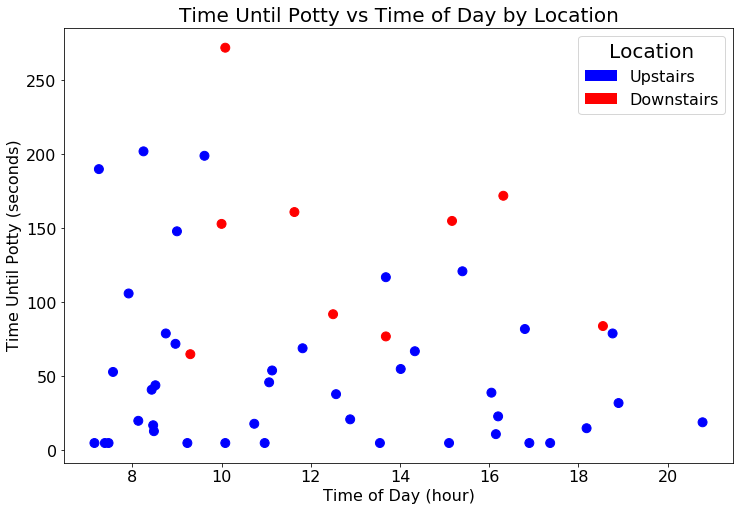

In [8]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

# Assume df is your potty DataFrame
# df.head()

# --- 1. Histogram of TuP ---
# plt.figure(figsize=(8,4))
# plt.hist(df['TuP'], bins=10, color='skyblue', edgecolor='black')
# plt.xlabel('Time until Potty (seconds)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Time until Potty (TuP)')
# # plt.show()

# # --- 2. Boxplots by location ---
# plt.figure(figsize=(10,8))
# # plt.boxplot([book_y, book_n], labels=['Book','No Book'])
# plt.ylabel('TuP (seconds)', fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# upstairs = df[df['location']=='Upstairs']['TuP']
# downstairs = df[df['location']=='Downstairs']['TuP']
# plt.title('TuP by Location', fontsize = 20)

# # plt.figure()
# plt.boxplot([upstairs, downstairs], labels=['Upstairs','Downstairs'])
# # plt.ylabel('TuP (seconds)')
# plt.show()

# # --- 3. Boxplots by outcome (#1 vs #2) ---
# pee = df[df['outcome']=='#1']['TuP']
# poop = df[df['outcome']=='#2']['TuP']

# plt.figure(figsize=(6,4))
# plt.boxplot([pee, poop], labels=['Pee (#1)','Poop (#2)'])
# plt.ylabel('TuP (seconds)')
# # plt.title('TuP by Outcome')
# # plt.show()

# # --- 4. Boxplots by book reading ---
# book_y = df[df['book']=='Y']['TuP'].copy()
# book_n = df[df['book']=='N']['TuP'].copy()

# plt.figure(figsize=(10,8))
# plt.boxplot([book_y, book_n], labels=['Book','No Book'])
# plt.ylabel('TuP (seconds)', fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.title('TuP vs Book Reading', fontsize = 20)
# plt.show()

# --- 5. TuP vs ToD scatter colored by location ---
colors = df['location'].map({'Upstairs':'blue','Downstairs':'red'})
plt.figure(figsize=(12,8))
plt.scatter(df['ToD'], df['TuP'], c=colors, s = 80)
plt.xlabel('Time of Day (hour)', fontsize = 16)
plt.xticks(fontsize = 16)
plt.ylabel('Time Until Potty (seconds)', fontsize = 16)
plt.yticks(fontsize = 16)
plt.title('Time Until Potty vs Time of Day by Location', fontsize = 20)
# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Upstairs'),
                   Patch(facecolor='red', label='Downstairs')]
plt.legend(handles=legend_elements, title='Location', fontsize = 16, title_fontsize = 20)
plt.savefig('tup_tod.png')
plt.show()

# # --- 6. Simple stats ---
# print("Mean TuP by location:")
# print(df.groupby('location')['TuP'].mean())
# print("\nMedian TuP by location:")
# print(df.groupby('location')['TuP'].median())
# print("\nCounts by location:")
# print(df['location'].value_counts())

# # --- 7. Basic hypothesis tests ---
# # Normality check
# stat, p = shapiro(upstairs)
# print(f"\nShapiro test Upstairs TuP: p={p:.3f}")
# stat, p = shapiro(downstairs)
# print(f"Shapiro test Downstairs TuP: p={p:.3f}")

# # Compare Upstairs vs Downstairs
# t_stat, t_p = ttest_ind(upstairs, downstairs)
# print(f"\nT-test Upstairs vs Downstairs: p={t_p:.3f}")

# u_stat, u_p = mannwhitneyu(upstairs, downstairs)
# print(f"Mann-Whitney Upstairs vs Downstairs: p={u_p:.3f}")


/home/simonhans/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1449: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


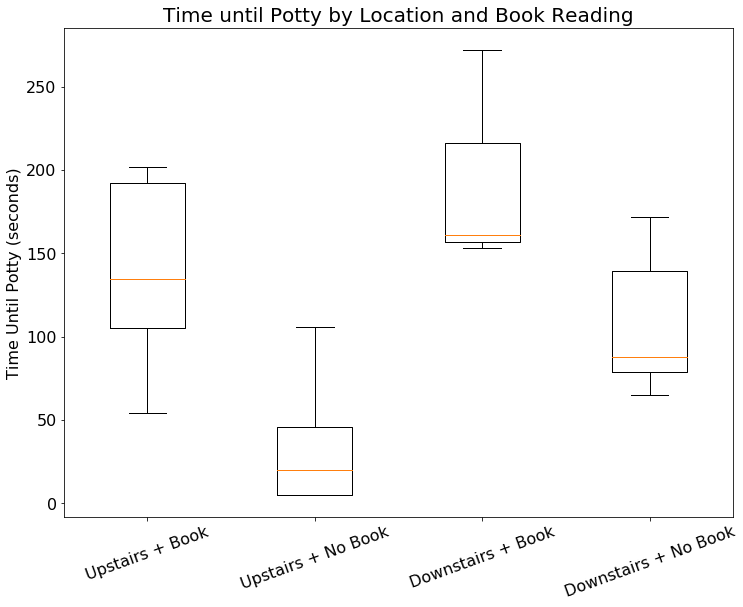

In [12]:
import matplotlib.pyplot as plt

# Define the four groups
groups = [
    df[(df['location']=='Upstairs') & (df['book']=='Y')]['TuP'],
    df[(df['location']=='Upstairs') & (df['book']=='N')]['TuP'],
    df[(df['location']=='Downstairs') & (df['book']=='Y')]['TuP'],
    df[(df['location']=='Downstairs') & (df['book']=='N')]['TuP']
]

# Labels for the boxes
labels = ['Upstairs + Book', 'Upstairs + No Book', 
          'Downstairs + Book', 'Downstairs + No Book']

plt.figure(figsize=(12,9))
plt.ylabel('TuP (seconds)', fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.boxplot(groups, labels=labels)
plt.ylabel('Time Until Potty (seconds)')
plt.title('Time until Potty by Location and Book Reading', fontsize = 20)
plt.xticks(rotation=20)
plt.savefig('tup_book.png')
plt.show()


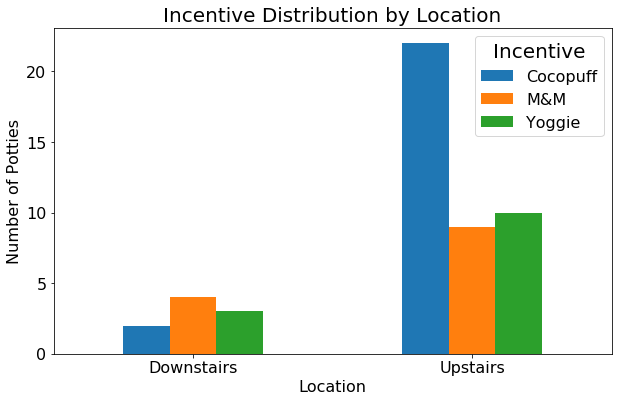

In [10]:
# Count number of each incentive by location
counts = df.groupby(['location','incentive']).size().unstack(fill_value=0)

# Plot
counts.plot(kind='bar', figsize=(10,6))
plt.ylabel('Number of Potties', fontsize = 16)
plt.yticks(fontsize = 16)
plt.title('Incentive Distribution by Location', fontsize = 20)
plt.xlabel('Location', fontsize = 16)
plt.xticks(fontsize = 16, rotation = 0)
plt.legend(title='Incentive', title_fontsize=20, fontsize=16)  # adjust title and label font sizes
plt.savefig('tup_inc.png')
plt.show()
